In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.random_search import RandomLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.grayscale.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 5)[0]]
MAX_WIDTH = 40
MAX_HEIGHT = 12
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return RandomLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        generations=400,
        **params.converter_args)


Min: -0.0197 | Max: 0.0773 | Mean: 0.0358 | Std: 0.0398
Min: -0.0119 | Max: 0.0887 | Mean: 0.0434 | Std: 0.0422
Min: 0.0100 | Max: 0.0959 | Mean: 0.0571 | Std: 0.0343
Min: -0.0022 | Max: 0.1075 | Mean: 0.0478 | Std: 0.0436
Min: 0.0116 | Max: 0.1061 | Mean: 0.0567 | Std: 0.0385


C:\Users\wojte\AppData\Local\Temp\ipykernel_9904\3906144444.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


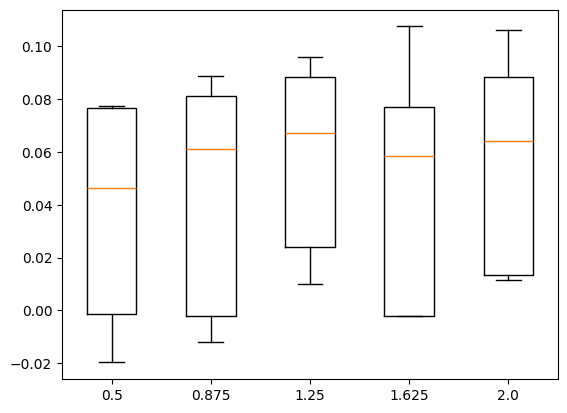

In [2]:
# contrast

params_space = [
    {'contrast': c, 'scale_factor': 0.3} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [3]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = RandomLineSearch(symbols=SYMBOLS,
                             font=FONT,
                             generations=400)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    font_height_px = FONT_SIZE * 1.333
    font_width_px = FONT_SIZE * 0.5
    scale_h = MAX_HEIGHT * font_height_px / img.height
    scale_w = MAX_WIDTH * font_width_px / img.width
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    results.append(converter.process_image(img))

print_gallery(results, 1)

----------------------------------------------
 | :I=wK=K=:wwKwKwwK:w:Kww:w:KwwwwK=Iw=K:== | 
 | :=:=ww:::I=:IwIII===K:KKI==:K:::=:w===:: | 
 | =:wwwKKwKwK:w=IKw:wKIww=KI:K=w=:I::===w: | 
 | Kw=K=wIK=:=I:KwKIK=KKwKKIIIKIw:KKKKKww=I | 
 | K:I=K=KKKIKKKIw==KKKK=wK:KwKK=K::KwwwwwK | 
 | KwKIwIKwwI=wK:K:KIKKKI=I=KwKKKKww:=KwKwK | 
 | KKww:IKwww:K=IK=:KIKwwwKKIKKKKw:ww==III= | 
 | :K:KKwKK==w:=:I:w:Kwww=wwI:KKKKwwKwKIKKw | 
 | KIKKwww=wwK:wwI:=Iw=KIwKwIwI==IKKwIwKIw= | 
 | IKwwwK=IK:KI:IKwKwwwIIIwwIKK=KwK:wKw:KwI | 
 | wIIKwKKwK:KKwwwKwwwI:KKKwI=:=I=KKww::=Iw | 
 | wKIK:IIKK::KKKKKK=wwIwwKwKK::KKw=wK=w=wI | 
 | =:wKK:wKKwwKKI=wwKI=K=KK==wIKI:ww=KKK=:: | 
----------------------------------------------
 | w=wK:Kw=KIwIK=ww:wwwI:w:wKw=wKKwIw=:KwKK | 
 | :KKw==KK:KKKKI:w=w=IwK=KK:=KIKww:wwKKI=K | 
 | :wK=KKw==KKKwKwKIwKI=wKIKwK:IIII:K=wKK=K | 
 | :::Iw:KKI:KKIw:=KwK:=KKKKwKI==w:K=I==I=: | 
 | w=KKww=KwwIw=Kw=IwK=I:wIKIK=:wwKwwwKwKIK | 
 | wwI=wK=KKwIIwwwK:::==KI:KKwK:K=IwwIKKKKK | 
 | w:KwwIKKKK